# Task 1: In-Silico Perturbation Workflow

## What this notebook does
Defines and demonstrates a reusable workflow for simulating gene 
knock-down and knock-up experiments using GeneFormer's rank-value encoding.

## Workflow
```
```
Load Data → Initialise Model → Apply Perturbation → Embed → Inspect Results

## Biological rationale

GeneFormer ranks genes by expression within each cell.  
Changing a gene’s expression therefore shifts its **rank in the token sequence**, which alters the model’s embedding representation.

Instead of forcing extreme expression values, we apply **gradual stochastic perturbations** that scale gene expression differently in each cell.

For a target gene *g* in cell *i*:

X' = X × exp(δ)

where:

- δ ~ Normal(μ, σ²)
- μ controls perturbation strength
- σ controls cell-to-cell heterogeneity

Perturbation modes:

- **Knock-up** → μ > 0 → expression increases
- **Knock-down** → μ < 0 → expression decreases

This produces **per-cell fold changes**, allowing the gene’s rank to shift naturally while introducing realistic biological variability across cells.

All logic lives in `src/perturbation.py`. This notebook runs and validates it.

### Imports

In [17]:
import sys
sys.path.append("..")

import logging
logging.basicConfig(level=logging.INFO)

import torch
import scipy.sparse as sp
import scanpy as sc
import anndata as ad
import numpy as np
from helical.models.geneformer import Geneformer, GeneformerConfig
from src.perturbation_v2 import (
    generate_perturbations,
    run_perturbation_pipeline
)

### Config

In [18]:
MODES           = ["knockdown", "knockup"]
DEMO_GENES      = ["TARDBP", "FUS", "SOD1"]
N_DEMO          = 100

### Load and inspect data

In [19]:
adata = ad.read_h5ad("../counts_combined_filtered_BA4_sALS_PN.h5ad")

print("=== AnnData Summary ===")
print(adata)
print("\n--- obs columns (cell metadata) ---")
print(adata.obs.columns.tolist())
print("\n--- var columns (gene metadata) ---")
print(adata.var.columns.tolist())
print("\n--- First 5 gene names ---")
print(adata.var_names[:5].tolist())
print("\n--- Disease label distribution ---")
print(adata.obs['Condition'].value_counts()) 

=== AnnData Summary ===
AnnData object with n_obs × n_vars = 112014 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'biotype'

--- obs columns (cell metadata) ---
['Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LV

### Critical: GeneFormer needs raw integer counts

- `adata.X` must contain **raw counts** (integers), NOT log-normalized values
- If `.raw` exists, restore it first
- We also confirm the gene name column that `process_data()` will use

In [20]:
# Restore raw counts if log-normalized data is currently in .X
if adata.raw is not None:
    print("Restoring raw counts from adata.raw")
    adata = adata.raw.to_adata()
else:
    print("No .raw found — assuming adata.X already contains raw counts")

# Confirm integer-like values (sample check)
sample = adata.X[:5, :5]
if sp.issparse(sample):
    sample = sample.toarray()
print("\nSample of count values (should be integers):")
print(sample)

# Identify the correct gene name column for process_data()
# Common options: 'gene_name', 'gene_symbols', index itself
print(f"\nUsing index column: 'Gene'")
print(adata.var.index[:5])

No .raw found — assuming adata.X already contains raw counts

Sample of count values (should be integers):
[[0 0 0 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 1 1 0]
 [0 0 2 0 0]]

Using index column: 'Gene'
Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'FGR'], dtype='object', name='Gene')


### Initialize GeneFormer Model

In [21]:
# Batch size and device configuration for GeneFormer
# Batch size determines how many cells are processed together during embedding computation. Adjust based on available GPU memory.

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_config = GeneformerConfig(
    model_name="gf-12L-95M-i4096",
    batch_size=16,
    device=device,
    nproc=8, 
)

geneformer = Geneformer(configurer=model_config)
geneformer.model.eval()
geneformer.model.config.output_hidden_states = False
geneformer.model.config.output_attentions = False
print("GeneFormer model loaded successfully.")

2026-03-09 22:05:47,461 - WARNING:helical.models.geneformer.geneformer_config:Setting model to gf-12L-38M-i4096. Model name gf-12L-95M-i4096 is deprecated. Please use the new name going forward to avoid code breakages.Geneformer models have been renamed to better reflect their size.


Using device: cpu


INFO:helical.models.geneformer.model:Model finished initializing.
2026-03-09 22:05:49,812 - INFO:helical.models.geneformer.model:Model finished initializing.
INFO:helical.models.geneformer.model:'gf-12L-38M-i4096' model is in 'eval' mode, on device 'cpu' with embedding mode 'cell'.
2026-03-09 22:05:49,815 - INFO:helical.models.geneformer.model:'gf-12L-38M-i4096' model is in 'eval' mode, on device 'cpu' with embedding mode 'cell'.


GeneFormer model loaded successfully.


## Step 1: Validate individual perturbation functions
Before running the full pipeline, confirm that generating perturbations with gradual knockdowns and knockups correctly modify the count matrix.

In [22]:
# Validate knockdown
demo = adata[:50].copy()
gene = "TARDBP"

before = demo[:, gene].X.toarray().flatten()
adata_kd = generate_perturbations(demo, gene_list=[gene], modes=["knockdown"], strength=1.0, heterogeneity=0.1)
after  = adata_kd["knockdown_TARDBP"][:, gene].X.toarray().flatten()

print(f"Before knockdown — mean expression: {before.mean():.2f}")
print(f"After  knockdown — mean expression: {after.mean():.2f}")
print("✓ Knockdown verified")

INFO:src.perturbation_v2:[1/1] Running knockdown_TARDBP
2026-03-09 22:06:02,211 - INFO:src.perturbation_v2:[1/1] Running knockdown_TARDBP
  self._set_arrayXarray(i, j, x)

2026-03-09 22:06:02,216 - WARNING:py.warnings:/Users/aseelawdeh/Documents/helical/als_perturbation/helical/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)

INFO:src.perturbation_v2:  ✓ knockdown_TARDBP | gene=TARDBP | col_idx=5015 | strength=1.00 | heterogeneity=0.10
2026-03-09 22:06:02,228 - INFO:src.perturbation_v2:  ✓ knockdown_TARDBP | gene=TARDBP | col_idx=5015 | strength=1.00 | heterogeneity=0.10


Before knockdown — mean expression: 0.80
After  knockdown — mean expression: 0.22
✓ Knockdown verified


In [25]:
dataset_base = geneformer.process_data(demo)
dataset_pert = geneformer.process_data(adata_kd["knockdown_TARDBP"])

changed = 0
total = len(dataset_base)

for i in range(total):
    if dataset_base[i]["input_ids"] != dataset_pert[i]["input_ids"]:
        changed += 1

print(f"Cells with changed tokens: {changed}/{total} ({changed/total:.2%})")

INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-09 22:06:57,669 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-03-09 22:06:58,438 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 50 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'E

Cells with changed tokens: 31/50 (62.00%)


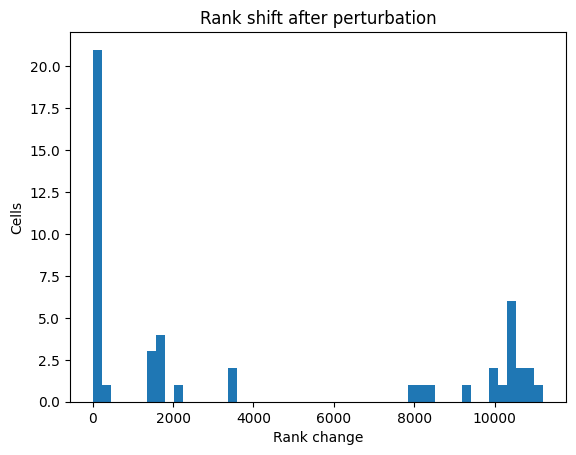

In [30]:
# Analyze rank shifts for the perturbed gene
# This function computes the rank of a specific gene's expression in each cell, 
# allowing us to see how the perturbation affects its relative expression compared to other genes.

def gene_rank(adata, gene):
    gene_idx = np.where(adata.var_names == gene)[0][0]
    X = adata.X.toarray()
    ranks = np.argsort(-X, axis=1)
    return np.where(ranks == gene_idx)[1]

rank_base = gene_rank(demo, "TARDBP")
rank_pert = gene_rank(adata_kd["knockdown_TARDBP"], "TARDBP")

shift = rank_pert - rank_base

import matplotlib.pyplot as plt

plt.hist(shift, bins=50)
plt.title("Rank shift after perturbation")
plt.xlabel("Rank change")
plt.ylabel("Cells")
plt.show()

In [6]:
# Validate knockup 
demo = adata[:50].copy()
gene = "TARDBP"

adata_ku = generate_perturbations(demo, gene_list=[gene], modes=["knockup"], strength=1.0, heterogeneity=0.1)
after_ku = adata_ku["knockup_TARDBP"][:, gene].X.toarray().flatten()

print(f"Before knockup — mean expression: {demo.X.mean():.2f}")
print(f"After  knockup — mean expression: {after_ku.mean():.2f}")
print("✓ Knockup verified")

INFO:src.perturbation_v2:[1/1] Running knockup_TARDBP
2026-03-07 03:54:04,567 - INFO:src.perturbation_v2:[1/1] Running knockup_TARDBP


INFO:src.perturbation_v2:  ✓ knockup_TARDBP | gene=TARDBP | col_idx=5015 | strength=1.00 | heterogeneity=0.10
2026-03-07 03:54:04,575 - INFO:src.perturbation_v2:  ✓ knockup_TARDBP | gene=TARDBP | col_idx=5015 | strength=1.00 | heterogeneity=0.10


Before knockup — mean expression: 0.85
After  knockup — mean expression: 2.26
✓ Knockup verified


## Step 2: Run the full perturbation pipeline
Baseline + all (gene × mode) combinations embedded in one call.


In [7]:
# For demonstration, we'll select a random subset of genes to perturb. In practice, you would choose genes based on biological relevance or specific hypotheses.
gene_idx = np.random.choice(adata.n_vars, 2000, replace=False)
adata_sub = adata[:, gene_idx].copy()
DEMO_GENES = adata_sub.var_names.values.tolist()[:3]

print(f"Selected {adata_sub.n_vars} genes for perturbation analysis")
print(f"DEMO_GENES: {DEMO_GENES}")

Selected 2000 genes for perturbation analysis
DEMO_GENES: ['KRTAP1-1', 'C2orf72', 'RUSC1']


In [8]:
# Run pipeline 
results = run_perturbation_pipeline(
    adata         = adata_sub,
    gene_list     = DEMO_GENES,
    modes         = MODES,
    model         = geneformer,
    cell_subset   = N_DEMO,
)

INFO:src.perturbation_v2:Starting perturbation pipeline.
2026-03-07 03:54:11,360 - INFO:src.perturbation_v2:Starting perturbation pipeline.
INFO:src.perturbation_v2:Genes: ['KRTAP1-1', 'C2orf72', 'RUSC1']
2026-03-07 03:54:11,361 - INFO:src.perturbation_v2:Genes: ['KRTAP1-1', 'C2orf72', 'RUSC1']
INFO:src.perturbation_v2:Modes: ['knockdown', 'knockup']
2026-03-07 03:54:11,362 - INFO:src.perturbation_v2:Modes: ['knockdown', 'knockup']
INFO:src.perturbation_v2:Computing baseline embeddings...
2026-03-07 03:54:11,363 - INFO:src.perturbation_v2:Computing baseline embeddings...
INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-07 03:54:11,363 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
INFO:helical.utils.mapping:Mapped 1998 / 2000 genes to Ensembl IDs.
2026-03-07 03:54:11,962 - INFO:helical.utils.mapping:Mapped 1998 / 2000 genes to Ensembl IDs.
INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 100 × 2

  0%|          | 0/7 [00:00<?, ?it/s]

INFO:helical.models.geneformer.model:Finished getting embeddings.
2026-03-07 03:54:19,368 - INFO:helical.models.geneformer.model:Finished getting embeddings.
INFO:src.perturbation_v2:[1/6] Running knockdown_KRTAP1-1
2026-03-07 03:54:19,372 - INFO:src.perturbation_v2:[1/6] Running knockdown_KRTAP1-1
  self._set_arrayXarray(i, j, x)

2026-03-07 03:54:19,373 - WARNING:py.warnings:/Users/aseelawdeh/Documents/helical/als_perturbation/helical/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)

INFO:src.perturbation_v2:  ✓ knockdown_KRTAP1-1 | gene=KRTAP1-1 | col_idx=0 | strength=10.00 | heterogeneity=0.10
2026-03-07 03:54:19,375 - INFO:src.perturbation_v2:  ✓ knockdown_KRTAP1-1 | gene=KRTAP1-1 | col_idx=0 | strength=10.00 | heterogeneity=0.10
INFO:src.perturbation_v2:[2/6] Running knockdown_C2orf72
2026-03-07 03:54:19,376 - INFO:src.pertu

  0%|          | 0/7 [00:00<?, ?it/s]

INFO:helical.models.geneformer.model:Finished getting embeddings.
2026-03-07 03:54:26,974 - INFO:helical.models.geneformer.model:Finished getting embeddings.
INFO:src.perturbation_v2:Running perturbation knockdown_C2orf72
2026-03-07 03:54:26,975 - INFO:src.perturbation_v2:Running perturbation knockdown_C2orf72
INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-07 03:54:26,976 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
INFO:helical.utils.mapping:Mapped 1998 / 2000 genes to Ensembl IDs.
2026-03-07 03:54:27,482 - INFO:helical.utils.mapping:Mapped 1998 / 2000 genes to Ensembl IDs.
INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 100 × 2000
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_

...

INFO:helical.models.geneformer.model:Finished getting embeddings.
2026-03-07 03:54:49,844 - INFO:helical.models.geneformer.model:Finished getting embeddings.
INFO:src.perturbation_v2:Running perturbation knockup_C2orf72
2026-03-07 03:54:49,844 - INFO:src.perturbation_v2:Running perturbation knockup_C2orf72
INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-07 03:54:49,845 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
INFO:helical.utils.mapping:Mapped 1998 / 2000 genes to Ensembl IDs.
2026-03-07 03:54:50,297 - INFO:helical.utils.mapping:Mapped 1998 / 2000 genes to Ensembl IDs.
INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 100 × 2000
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_tota

  0%|          | 0/7 [00:00<?, ?it/s]

INFO:helical.models.geneformer.model:Finished getting embeddings.
2026-03-07 03:54:57,366 - INFO:helical.models.geneformer.model:Finished getting embeddings.
INFO:src.perturbation_v2:Running perturbation knockup_RUSC1
2026-03-07 03:54:57,366 - INFO:src.perturbation_v2:Running perturbation knockup_RUSC1
INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-07 03:54:57,367 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
INFO:helical.utils.mapping:Mapped 1998 / 2000 genes to Ensembl IDs.
2026-03-07 03:54:57,947 - INFO:helical.utils.mapping:Mapped 1998 / 2000 genes to Ensembl IDs.
INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 100 × 2000
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_co

  0%|          | 0/7 [00:00<?, ?it/s]

INFO:helical.models.geneformer.model:Finished getting embeddings.
2026-03-07 03:55:04,950 - INFO:helical.models.geneformer.model:Finished getting embeddings.
INFO:src.perturbation_v2:Perturbation pipeline complete. 2 conditions embedded.
2026-03-07 03:55:04,950 - INFO:src.perturbation_v2:Perturbation pipeline complete. 2 conditions embedded.


In [13]:
# access first part of tuple
results[0].keys()


dict_keys(['baseline', 'perturbations'])

In [14]:
# Inspect results: baseline and perturbations
baseline_emb = results[0]["baseline"]
print(f"{'Baseline':35s}  shape: {baseline_emb.shape}")

for label, emb in results[0]["perturbations"].items():
    print(f"{label:35s}  shape: {emb.shape}")

Baseline                             shape: (100, 512)
knockdown_KRTAP1-1                   shape: (100, 512)
knockdown_C2orf72                    shape: (100, 512)
knockdown_RUSC1                      shape: (100, 512)
knockup_KRTAP1-1                     shape: (100, 512)
knockup_C2orf72                      shape: (100, 512)
knockup_RUSC1                        shape: (100, 512)


In [15]:
# Sanity check: perturbation moved embeddings 
from sklearn.metrics.pairwise import cosine_distances

baseline = results[0]["baseline"]

print(f"\n{'Condition':35s}  Cosine distance from baseline")
print("-" * 60)
for label, emb in results[0]["perturbations"].items():
    dist = cosine_distances(
        baseline.mean(axis=0, keepdims=True),
        emb.mean(axis=0, keepdims=True)
    )[0, 0]
    print(f"{label:35s}  {dist:.4f}")


Condition                            Cosine distance from baseline
------------------------------------------------------------
knockdown_KRTAP1-1                   0.0001
knockdown_C2orf72                    0.0001
knockdown_RUSC1                      0.0001
knockup_KRTAP1-1                     0.0001
knockup_C2orf72                      0.0001
knockup_RUSC1                        0.0001


In [ ]:
# Save for Notebook
import numpy as np
np.savez("../outputs/task1/perturbation_results_demo.npz", **results)
print("Saved to ../output/task1/perturbation_results_demo.npz")

Saved to ../data/perturbation_results_demo.npz


## Summary

| Step | What happens | Where |
|---|---|---|
| Load data | Read `.h5ad`, confirm raw counts | This notebook |
| Perturbation functions | Zero / amplify gene expression | `src/perturbation.py` |
| Embedding | GeneFormer encodes perturbed cells | `src/perturbation.py` |
| Results | Dict of `{label: embedding array}` | |

The workflow scales to any number of genes — just extend `DEMO_GENES`.

**Next:** Notebook 02 applies this to the full ALS gene panel.